This notebook is for symbol design/debugging only.
Real code lives in audiogram_render.py.

In [44]:
# --- Cell 1: imports + live-reload + config ---

%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import audiogram_object.symbols as sym
import audiogram_object.render_mpl as rm

import audiogram_object.symbols as sym

import importlib


# 1) One GEOM you are actively tuning (NR_START + bone geometry + NR arrow)
geom = sym.SymbolGeometryConfig(
    chevron_half_height=1.2,
    bracket_half_height=1.2,
    # ... any geometry tweaks ...
        # NR arrow geometry (local coords)
    nr_stem_len=1.0,
    nr_head_len=0.5,
    nr_head_angle_deg=32.0,
    nr_start=sym.NRStartConfig(
        O=(-0.80, -0.60),
        X=(0.6, -0.6),
        TRI=(-1.0, -1.0),
        SQ=(1.0, -1.0),
        CHEV_R=(-0.30, -1.1),
        CHEV_L=(0.30, -1.1),
        BRACK_R=(-0.30, -1.2),
        BRACK_L=(0.30, -1.2),
    ),
    nr_scale=sym.NRScaleConfig(
        CHEV_R=1.0, CHEV_L=1.0,
        BRACK_R=1.0, BRACK_L=1.0,
    ),
)

# 2) Real plot config
cfg_plot = sym.AudiogramRenderConfig(
    geom=geom,
    style=sym.RenderStyleConfig(air_size_pt=14, bone_size_pt=18, linewidth=1.5),
)

# 3) Gallery config (same geom, larger style)
cfg_gallery = sym.AudiogramRenderConfig(
    geom=geom,
    style=sym.RenderStyleConfig(air_size_pt=28, bone_size_pt=32, linewidth=2.2),
)

importlib.reload(sym)
importlib.reload(rm)
sym.clear_symbol_caches()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


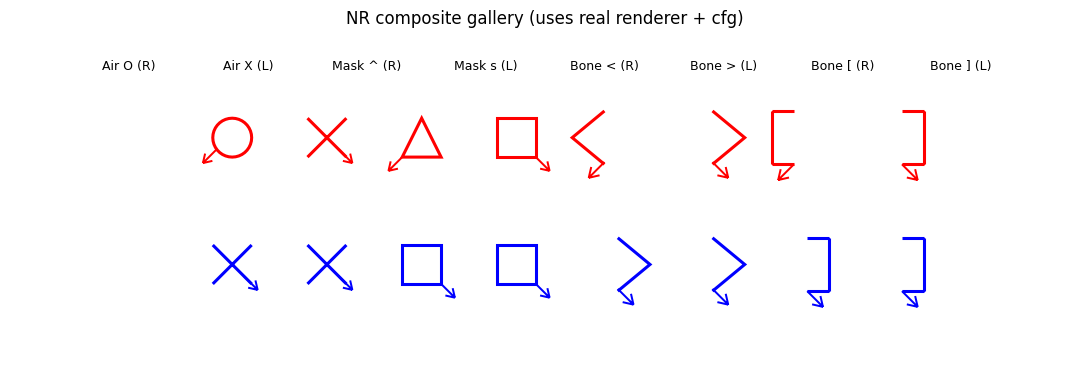

In [31]:
# --- Cell 2: NR gallery (use this to tune NR_START + NR arrow geometry) ---

def demo_nr_gallery(cfg):
    # Each entry is a "canonical" symbol you actually care about
    items = [
        ("Air O (R)",   dict(kind="air",  ear="right", masked=False)),
        ("Air X (L)",   dict(kind="air",  ear="left",  masked=False)),
        ("Mask ^ (R)",  dict(kind="air",  ear="right", masked=True)),
        ("Mask s (L)",  dict(kind="air",  ear="left",  masked=True)),
        ("Bone < (R)",  dict(kind="bone", ear="right", masked=False)),
        ("Bone > (L)",  dict(kind="bone", ear="left",  masked=False)),
        ("Bone [ (R)",  dict(kind="bone", ear="right", masked=True)),
        ("Bone ] (L)",  dict(kind="bone", ear="left",  masked=True)),
    ]

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.set_xlim(0, len(items) + 1)
    ax.set_ylim(0, 3.4)
    ax.axis("off")

    for i, (label, params) in enumerate(items, start=1):
        x0 = i

        # RIGHT ear composite (red) on top row
        sym_r = sym.get_symbol(**params, nr=True, cfg=cfg)
        if params["kind"] == "air":
            rm.draw_air_symbol(ax, sym_r, x0, 2.3, cfg=cfg, color="red", zorder=3)
        else:
            rm.draw_bone_symbol(ax, sym_r, x0, 2.3, cfg=cfg, color="red", zorder=3)

        # LEFT ear composite (blue) on bottom row
        params_l = dict(params)
        params_l["ear"] = "left"
        sym_l = sym.get_symbol(**params_l, nr=True, cfg=cfg)
        if params_l["kind"] == "air":
            rm.draw_air_symbol(ax, sym_l, x0, 0.9, cfg=cfg, color="blue", zorder=3)
        else:
            rm.draw_bone_symbol(ax, sym_l, x0, 0.9, cfg=cfg, color="blue", zorder=3)

        ax.text(x0, 3.05, label, ha="center", va="bottom", fontsize=9)

    ax.set_title("NR composite gallery (uses real renderer + cfg)", pad=10)
    plt.tight_layout()
    plt.show()

demo_nr_gallery(cfg_gallery)

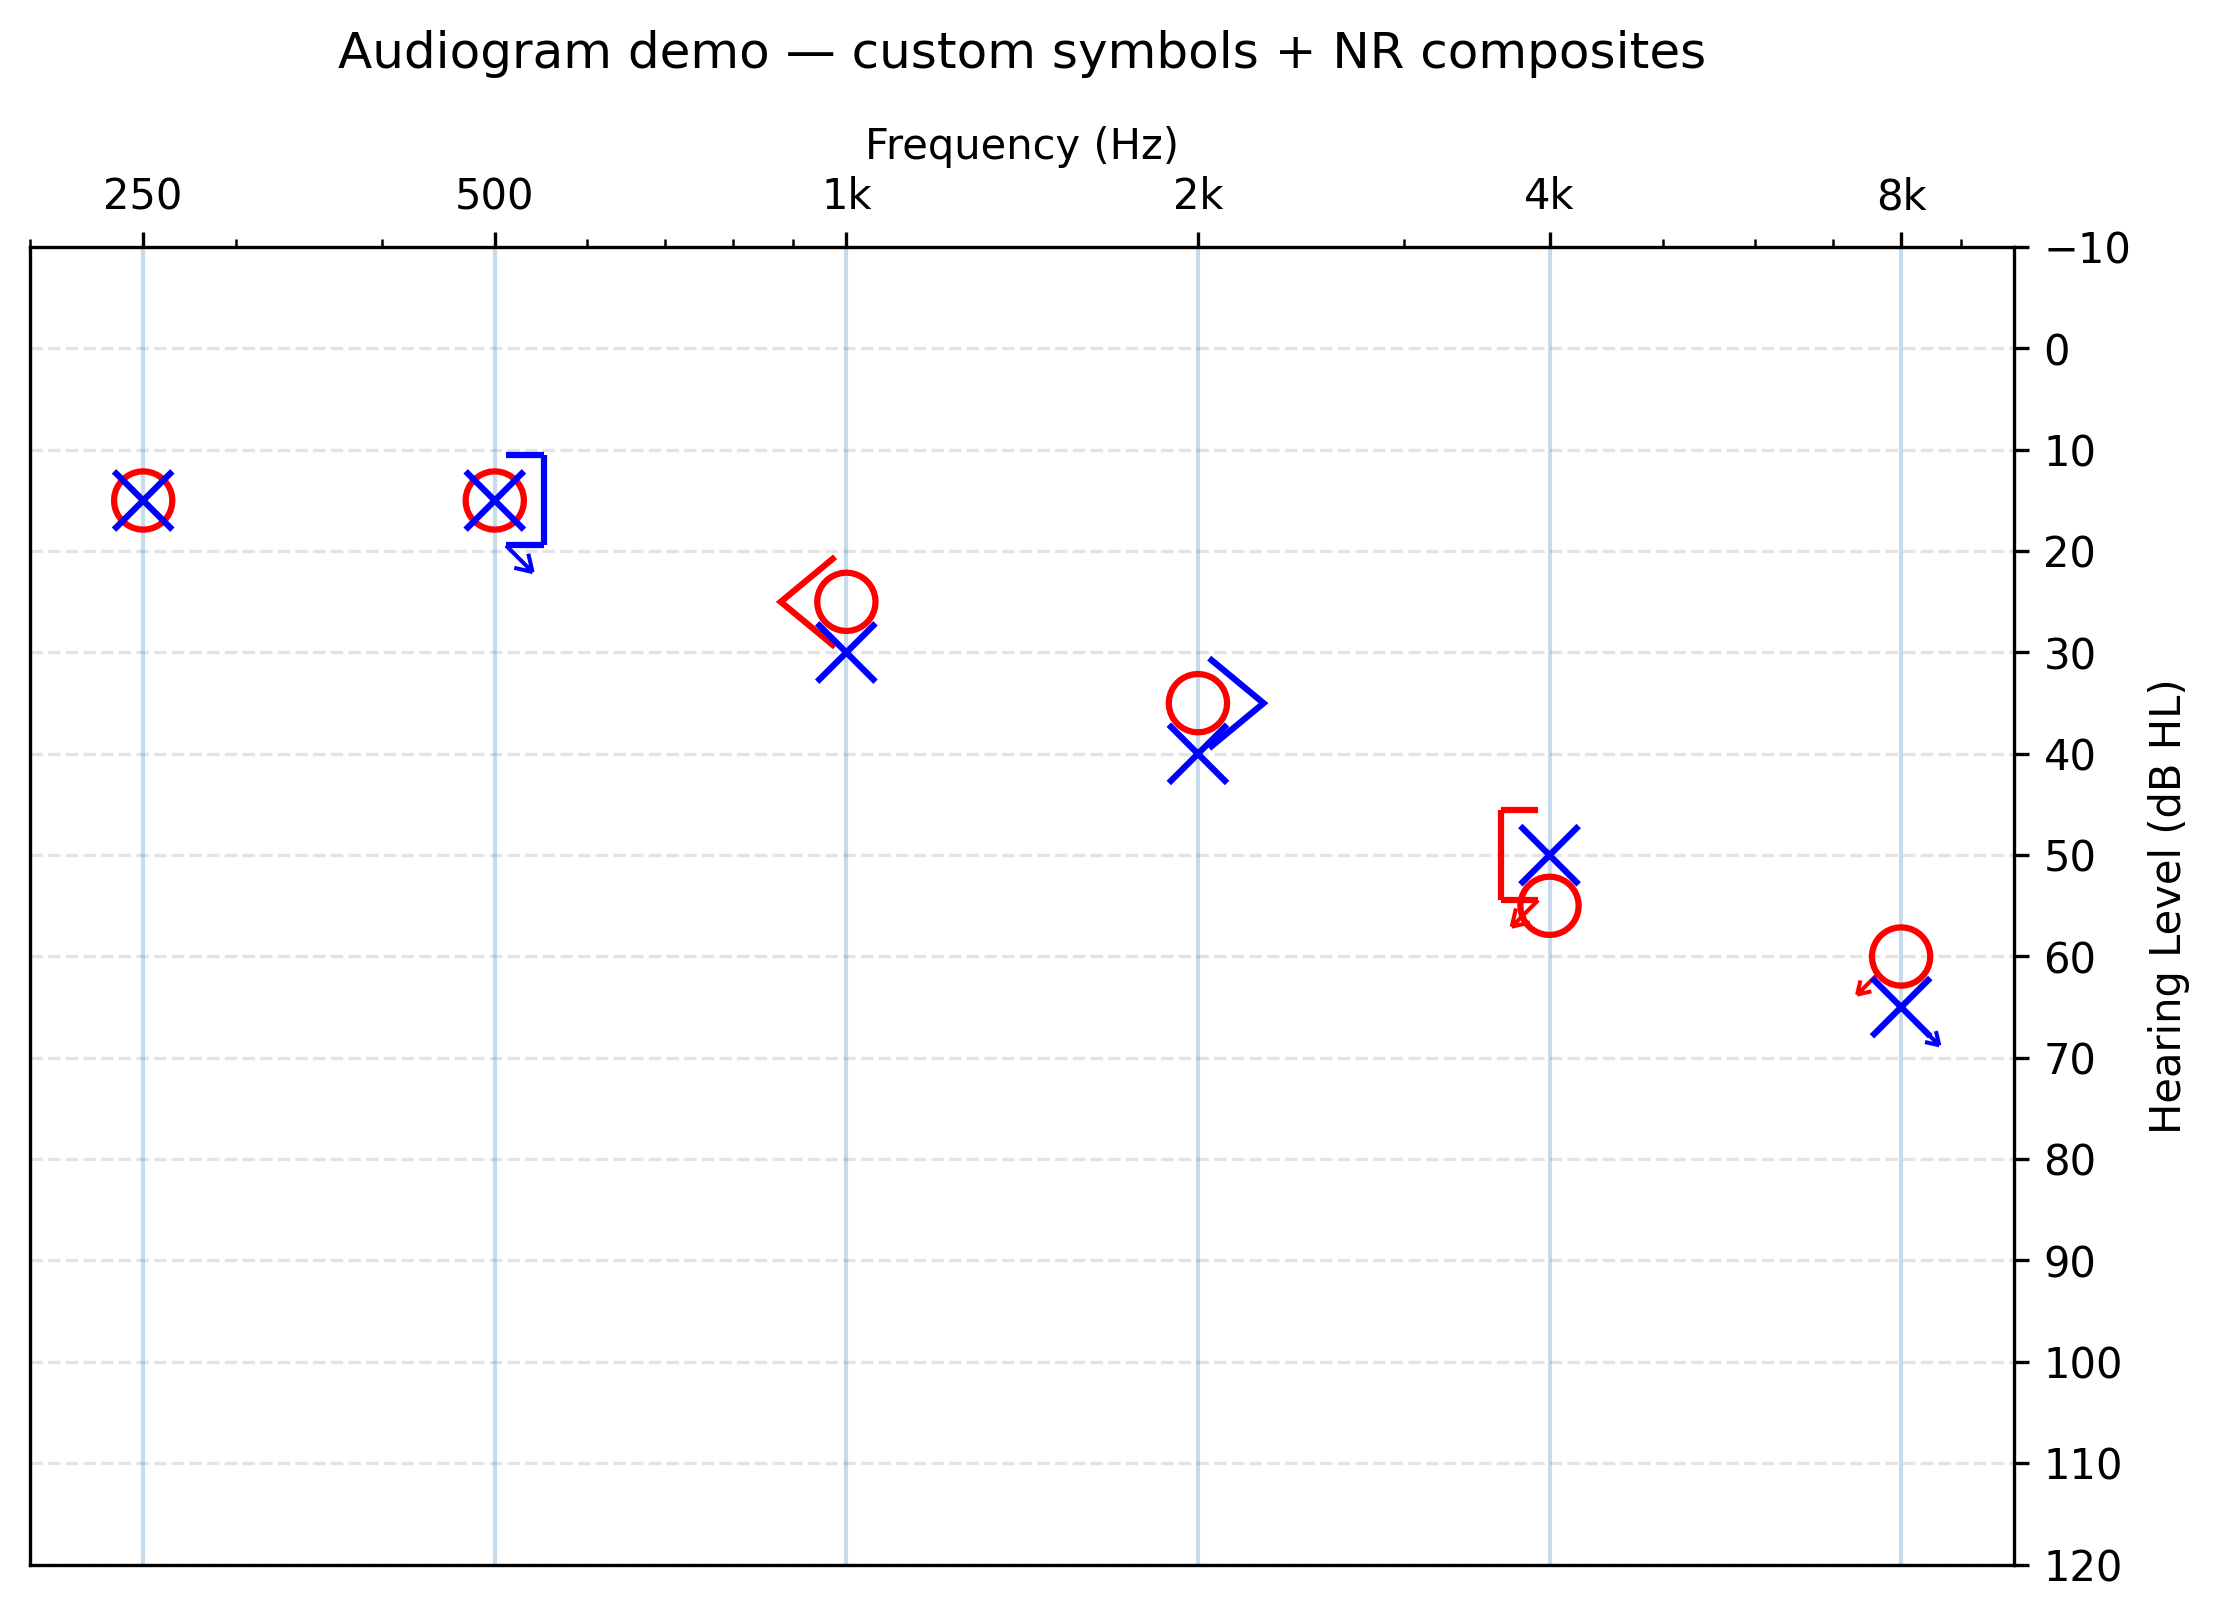

In [49]:
# --- Cell 3: audiogram plot demo ---

def demo_audiogram_plot(cfg):
    fig, ax = plt.subplots(figsize=(7.5, 5.5), dpi=300)

    # Axes first (important)
    ax.set_xscale("log")
    ax.set_xlim(200, 10000)   # or (125, 16000) if you want full ANSI range
    ax.set_xticks([250, 500, 1000, 2000, 4000, 8000])
    ax.set_xticklabels(["250", "500", "1k", "2k", "4k", "8k"])
    ax.tick_params(axis="x", which="both", bottom=False, top=True,
                   labelbottom=False, labeltop=True)
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("Frequency (Hz)")

    # Choose ONE y inversion style (do NOT double invert)
    ax.set_ylim(120, -10)  # already inverted
    ax.set_yticks(np.arange(-10, 121, 10))
    ax.set_ylabel("Hearing Level (dB HL)")
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")

    # Grid
    for f in [250, 500, 1000, 2000, 4000, 8000]:
        ax.axvline(f, linewidth=1, alpha=0.25)
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

    # Example data
    freqs = np.array([250, 500, 1000, 2000, 4000, 8000])
    thr_air_r = np.array([15, 15, 25, 35, 55, 60])
    thr_air_l = np.array([15, 15, 30, 40, 50, 65])

    nr_r_idx = {5}  # 4k
    nr_l_idx = {5}  # 8k

    # Air markers
    for i, (f, y) in enumerate(zip(freqs, thr_air_r)):
        s = sym.get_symbol(kind="air", ear="right", masked=False, nr=(i in nr_r_idx), cfg=cfg)
        rm.add_air_symbol(ax, s, float(f), float(y), cfg=cfg, color="red", zorder=4)

    for i, (f, y) in enumerate(zip(freqs, thr_air_l)):
        s = sym.get_symbol(kind="air", ear="left", masked=False, nr=(i in nr_l_idx), cfg=cfg)
        rm.add_air_symbol(ax, s, float(f), float(y), cfg=cfg, color="blue", zorder=4)

    # Bone examples
    bone_points = [
        (1000, 25, "right", False, "red",  False),
        (2000, 35, "left",  False, "blue", False),
        (4000, 50, "right", True,  "red",  True),
        (500,  15, "left",  True,  "blue", True),
    ]
    for f, y, ear, masked, color, nr in bone_points:
        s = sym.get_symbol(kind="bone", ear=ear, masked=masked, nr=nr, cfg=cfg)
        rm.add_bone_symbol(ax, s, float(f), float(y), cfg=cfg, color=color, zorder=3)

    ax.set_title("Audiogram demo — custom symbols + NR composites", pad=14)
    plt.tight_layout()
    plt.show()

demo_audiogram_plot(sym.DEFAULT_RENDER_CONFIG)

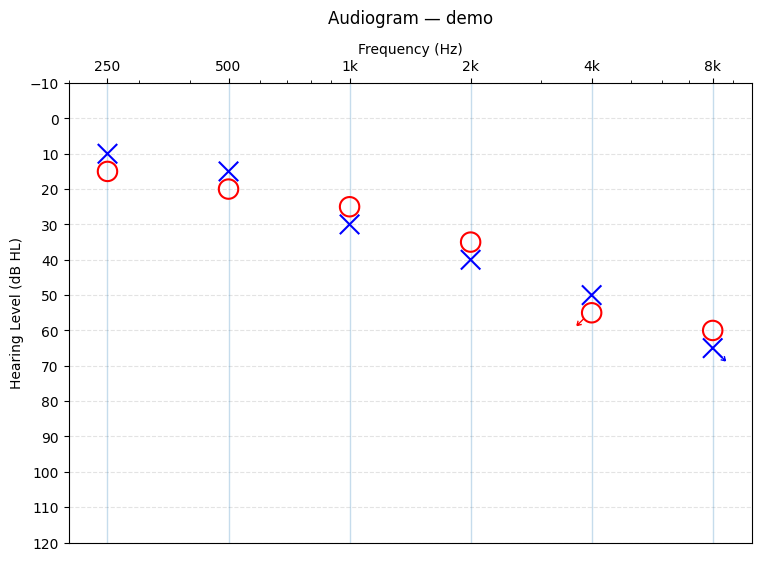

In [51]:
import importlib
from audiogram_object import plot_mpl as pm
importlib.reload(pm)

from audiogram_object import symbols as sym

# Canonical ANSI canvas + plot both ears
fig, ax = pm.plot_binaural(
    left={250: 10, 500: 15, 1000: 30, 2000: 40, 4000: 50, 8000: 65},
    right={250: 15, 500: 20, 1000: 25, 2000: 35, 4000: 55, 8000: 60},
    cfg=sym.DEFAULT_RENDER_CONFIG,
    preset="ansi",
    title="Audiogram — demo",
    left_nr=[8000],
    right_nr=[4000],
)
plt.show()

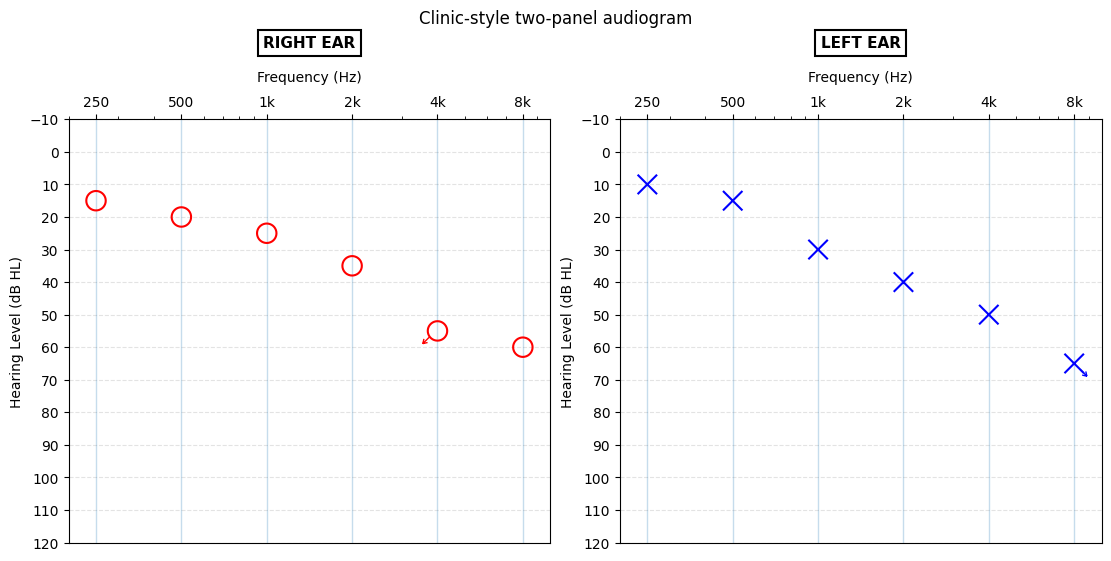

In [54]:
from audiogram_object import plot_mpl as pm
from audiogram_object import symbols as sym

fig, (ax_r, ax_l) = pm.plot_binaural_two_panel(
    right={250: 15, 500: 20, 1000: 25, 2000: 35, 4000: 55, 8000: 60},
    left ={250: 10, 500: 15, 1000: 30, 2000: 40, 4000: 50, 8000: 65},
    cfg=sym.DEFAULT_RENDER_CONFIG,
    preset="ansi",
    title="Clinic-style two-panel audiogram",
    right_nr=[4000],
    left_nr=[8000],
)
plt.show()